本圖呈現各大樓於每日 8–16 時之課堂數與用電功率變化，並以雙軸方式比較兩者之時間趨勢。為避免不同量綱造成誤判，先將資料進行標準化處理，並計算兩者之差距以找出差異最大之時間點。從趨勢可以發現除了中午12點外，其餘時段課堂數跟用電功率基本呈現正相關。圖中以陰影區域標示該時段，顯示在部分時段中，即使課堂數下降，用電功率仍維持高水準，反映出基礎用電或非教學耗能之存在。

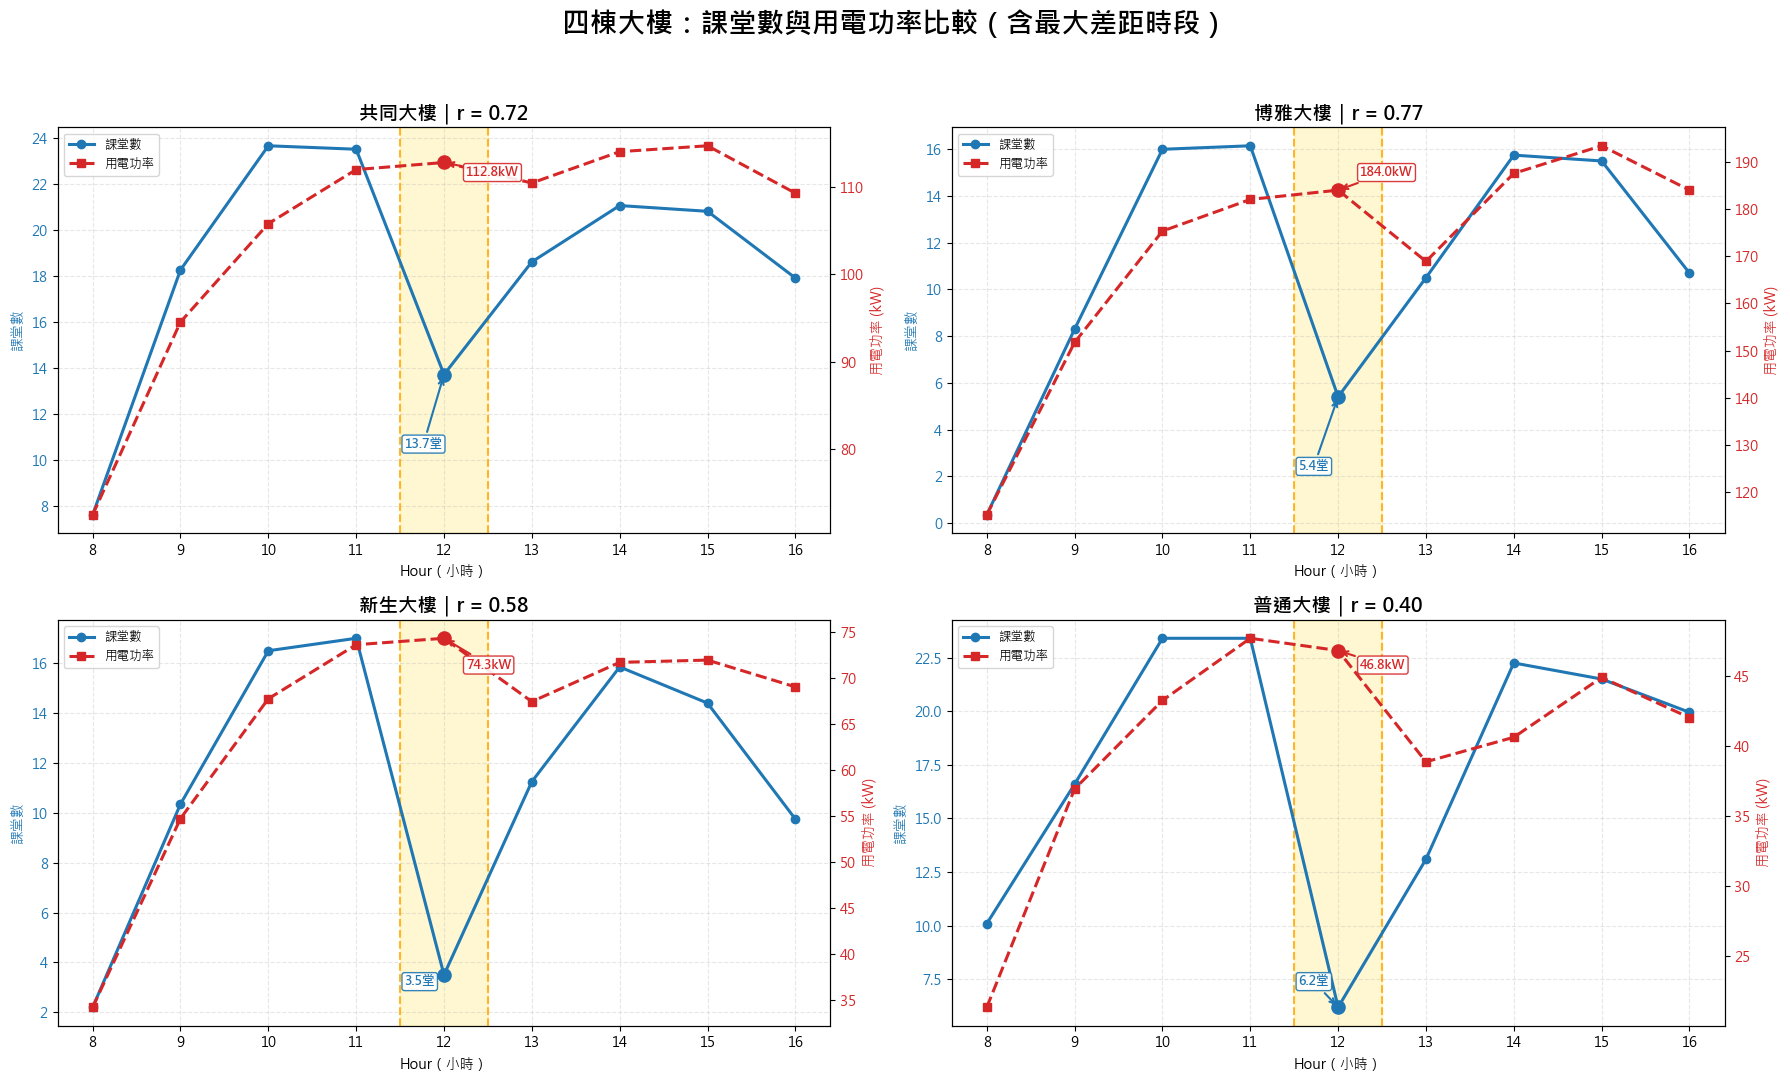

In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

folder = r"C:\Users\admin\Desktop\環保能源\團體專題\final_project-data-preprocessing\output"
output_folder = r"C:\Users\admin\Desktop\環保能源\團體專題\output"
os.makedirs(output_folder, exist_ok=True)

buildings = ["共同", "博雅", "新生", "普通"]

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes = axes.flatten()

for i, b in enumerate(buildings):
    ax1 = axes[i]

    usage = pd.read_csv(os.path.join(folder, f"{b}_classroom_usage_day.csv"))
    power = pd.read_csv(os.path.join(folder, f"{b}_power_day.csv"))

    usage_melt = usage.melt(
        id_vars=["學年度學期", "星期"],
        var_name="時間區間",
        value_name="課堂數"
    )

    usage_melt["hour"] = usage_melt["時間區間"].str.slice(0, 2).astype(int)
    usage_melt = usage_melt[(usage_melt["hour"] >= 8) & (usage_melt["hour"] <= 16)]
    usage_avg = usage_melt.groupby("hour")["課堂數"].mean().reset_index()

    power_filtered = power[(power["小時"] >= 8) & (power["小時"] <= 16)]
    power_avg = power_filtered.groupby("小時")["平均功率_kW"].mean().reset_index()
    power_avg.rename(columns={"小時": "hour"}, inplace=True)

    df = pd.merge(usage_avg, power_avg, on="hour")
    corr = df["課堂數"].corr(df["平均功率_kW"])

    # 找差距最大時間點：先標準化再比較
    norm_usage = (df["課堂數"] - df["課堂數"].min()) / (df["課堂數"].max() - df["課堂數"].min())
    norm_power = (df["平均功率_kW"] - df["平均功率_kW"].min()) / (df["平均功率_kW"].max() - df["平均功率_kW"].min())
    df["差距"] = abs(norm_usage - norm_power)

    max_idx = df["差距"].idxmax()
    max_hour = df.loc[max_idx, "hour"]
    max_usage = df.loc[max_idx, "課堂數"]
    max_power = df.loc[max_idx, "平均功率_kW"]

    # 背景標出最大差距時段
    ax1.axvspan(max_hour - 0.5, max_hour + 0.5, color="gold", alpha=0.18)
    ax1.axvline(max_hour - 0.5, color="orange", linestyle="--", alpha=0.8)
    ax1.axvline(max_hour + 0.5, color="orange", linestyle="--", alpha=0.8)

    ax2 = ax1.twinx()

    line1, = ax1.plot(
        df["hour"], df["課堂數"],
        color="tab:blue",
        marker="o",
        linewidth=2.2,
        label="課堂數"
    )

    line2, = ax2.plot(
        df["hour"], df["平均功率_kW"],
        color="tab:red",
        marker="s",
        linestyle="--",
        linewidth=2.2,
        label="用電功率"
    )

    # 最大差距點
    ax1.scatter(max_hour, max_usage, color="tab:blue", s=90, zorder=5)
    ax2.scatter(max_hour, max_power, color="tab:red", s=90, zorder=5)

    # 標註位置
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()
    y1_range = y1_max - y1_min
    y2_range = y2_max - y2_min

    usage_text_y = max(max_usage - 0.18 * y1_range, y1_min + 0.10 * y1_range)
    power_text_y = min(max_power + 0.12 * y2_range, y2_max - 0.12 * y2_range)

    ax1.annotate(
        f"{max_usage:.1f}堂",
        xy=(max_hour, max_usage),
        xytext=(max_hour - 0.45, usage_text_y),
        fontsize=9,
        color="tab:blue",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="tab:blue", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="tab:blue", lw=1.5)
    )

    ax2.annotate(
        f"{max_power:.1f}kW",
        xy=(max_hour, max_power),
        xytext=(max_hour + 0.25, power_text_y),
        fontsize=9,
        color="tab:red",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="tab:red", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.5)
    )

  

    ax1.set_title(f"{b}大樓｜r = {corr:.2f}", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Hour（小時）")
    ax1.set_ylabel("課堂數", color="tab:blue")
    ax2.set_ylabel("用電功率 (kW)", color="tab:red")

    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.set_xticks(df["hour"])
    ax1.grid(True, linestyle="--", alpha=0.3)

    lines = [line1, line2]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left", fontsize=9)

plt.suptitle(
    "四棟大樓：課堂數與用電功率比較（含最大差距時段）",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

save_path = os.path.join(output_folder, "四棟大樓_課堂數_vs_用電功率_合併比較_含最大差距.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

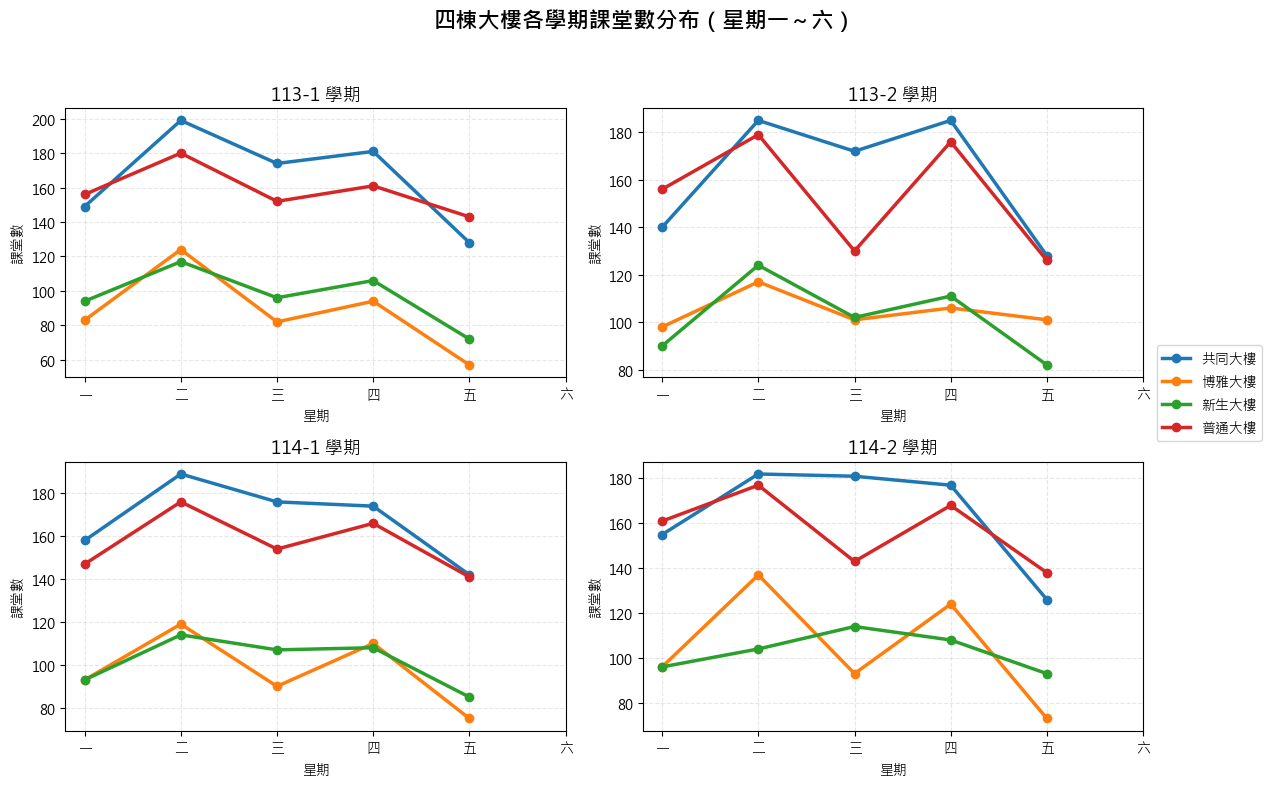

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

folder = r"C:\Users\admin\Desktop\環保能源\團體專題\final_project-data-preprocessing\output"

buildings = ["共同", "博雅", "新生", "普通"]
semesters = ["1131", "1132", "1141", "1142"]

weekday_map = {
    "星期一": 1,
    "星期二": 2,
    "星期三": 3,
    "星期四": 4,
    "星期五": 5,
    "星期六": 6
}

weekday_labels = ["一", "二", "三", "四", "五", "六"]

colors = {
    "共同": "#1f77b4",
    "博雅": "#ff7f0e",
    "新生": "#2ca02c",
    "普通": "#d62728"
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, sem in enumerate(semesters):
    ax = axes[i]

    for b in buildings:
        df = pd.read_csv(os.path.join(folder, f"{b}_classroom_usage_day.csv"))
        df.columns = df.columns.str.strip()

        sem_col = "學年度學期" if "學年度學期" in df.columns else "年度學期"

        df["學期_clean"] = df[sem_col].astype(str).str.replace("-", "", regex=False).str.strip()
        df_sem = df[df["學期_clean"] == sem].copy()

        df_sem = df_sem[df_sem["星期"].isin(weekday_map.keys())]

        time_cols = [
            c for c in df_sem.columns
            if ":" in c or "-" in c
        ]

        df_sem["課堂數"] = df_sem[time_cols].sum(axis=1)

        df_plot = df_sem.groupby("星期")["課堂數"].sum().reset_index()
        df_plot["weekday_num"] = df_plot["星期"].map(weekday_map)
        df_plot = df_plot.sort_values("weekday_num")

        ax.plot(
            df_plot["weekday_num"],
            df_plot["課堂數"],
            marker="o",
            linewidth=2.5,
            color=colors[b],
            label=f"{b}大樓"
        )

    ax.set_title(f"{sem[:3]}-{sem[3]} 學期", fontsize=13)
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(weekday_labels)
    ax.set_xlabel("星期")
    ax.set_ylabel("課堂數")
    ax.grid(True, linestyle="--", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    frameon=True
)

plt.suptitle("四棟大樓各學期課堂數分布（星期一～六）", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 0.90, 0.95])
plt.show()


共同 113-1 資料筆數: 63
博雅 113-1 資料筆數: 63
新生 113-1 資料筆數: 63
普通 113-1 資料筆數: 63
共同 113-2 資料筆數: 63
博雅 113-2 資料筆數: 63
新生 113-2 資料筆數: 63
普通 113-2 資料筆數: 63
共同 114-1 資料筆數: 63
博雅 114-1 資料筆數: 63
新生 114-1 資料筆數: 63
普通 114-1 資料筆數: 63
共同 114-2 資料筆數: 63
博雅 114-2 資料筆數: 63
新生 114-2 資料筆數: 63
普通 114-2 資料筆數: 63


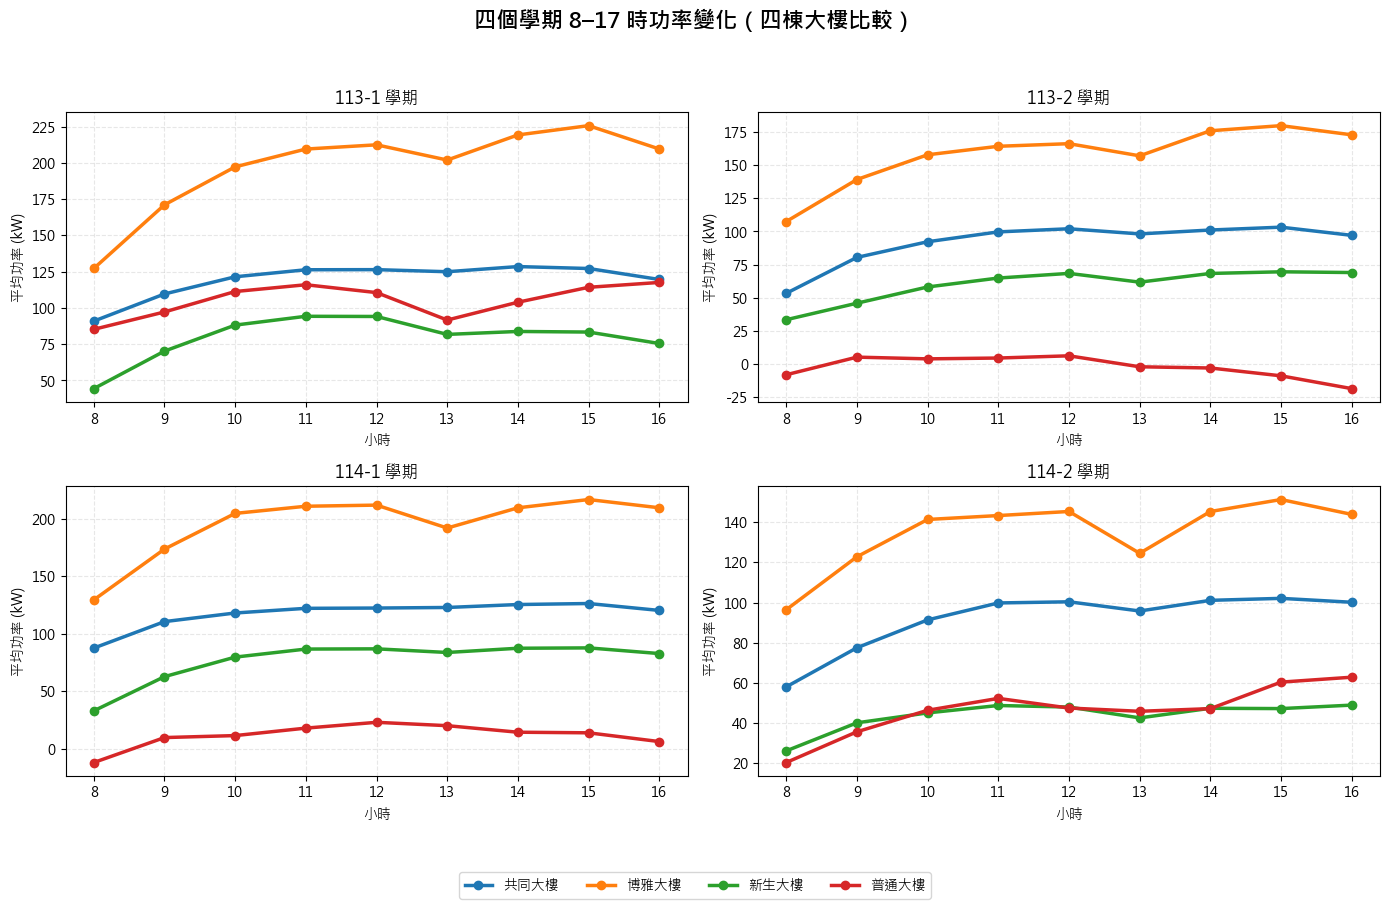

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

folder = r"C:\Users\admin\Desktop\環保能源\團體專題\final_project-data-preprocessing\output"

buildings = ["共同", "博雅", "新生", "普通"]
building_colors = {
    "共同": "#1f77b4",  # 藍
    "博雅": "#ff7f0e",  # 橘
    "新生": "#2ca02c",  # 綠
    "普通": "#d62728"   # 紅
}
semesters = {
    "1131": "113-1",
    "1132": "113-2",
    "1141": "114-1",
    "1142": "114-2"
}

hours = list(range(8, 17))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (sem_code, sem_label) in enumerate(semesters.items()):
    ax = axes[i]

    for b in buildings:
        df = pd.read_csv(os.path.join(folder, f"{b}_power_day.csv"))
        df.columns = df.columns.str.strip()

        df["年度學期_clean"] = df["年度學期"].astype(str).str.replace("-", "").str.strip()
        df["小時"] = pd.to_numeric(df["小時"], errors="coerce")
        df["平均功率_kW"] = pd.to_numeric(df["平均功率_kW"], errors="coerce")

        df_sem = df[
            (df["年度學期_clean"] == sem_code) &
            (df["小時"].between(8, 16))
        ]

        print(b, sem_label, "資料筆數:", len(df_sem))

        df_avg = df_sem.groupby("小時")["平均功率_kW"].mean().reset_index()

        ax.plot(
            df_avg["小時"],
            df_avg["平均功率_kW"],
            marker="o",
            linewidth=2.5,
            label=f"{b}大樓"
        )

    ax.set_title(f"{sem_label} 學期")
    ax.set_xlabel("小時")
    ax.set_ylabel("平均功率 (kW)")
    ax.set_xticks(hours)
    ax.grid(True, linestyle="--", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=4
)

plt.suptitle("四個學期 8–17 時功率變化（四棟大樓比較）", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

此圖用來量化課堂活動與用電之間的偏離程度，結果顯示所有大樓在中午 12 點存在明顯異常，顯示該時段為能源管理優化的關鍵。 推斷原因是由於有些學生會買午餐至教室用食或小憩，因此即使沒有課，仍會出現教室有在使用的情形，這可能也導致中午十二點課堂數跟用電量有如此大差距的原因。

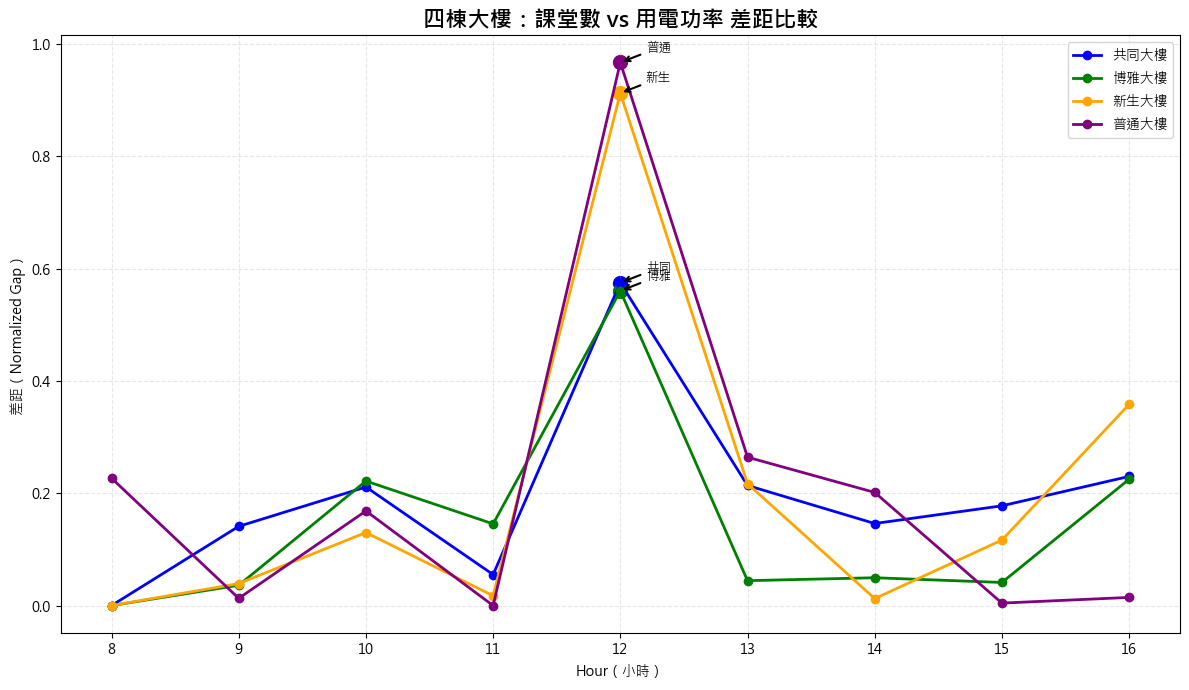

In [34]:
plt.figure(figsize=(12, 7))

colors = ["blue", "green", "orange", "purple"]

for i, b in enumerate(buildings):
    usage = pd.read_csv(os.path.join(folder, f"{b}_classroom_usage_day.csv"))
    power = pd.read_csv(os.path.join(folder, f"{b}_power_day.csv"))

    usage_melt = usage.melt(
        id_vars=["學年度學期", "星期"],
        var_name="時間區間",
        value_name="課堂數"
    )

    usage_melt["hour"] = usage_melt["時間區間"].str.slice(0, 2).astype(int)
    usage_melt = usage_melt[(usage_melt["hour"] >= 8) & (usage_melt["hour"] <= 16)]
    usage_avg = usage_melt.groupby("hour")["課堂數"].mean().reset_index()

    power_filtered = power[(power["小時"] >= 8) & (power["小時"] <= 16)]
    power_avg = power_filtered.groupby("小時")["平均功率_kW"].mean().reset_index()
    power_avg.rename(columns={"小時": "hour"}, inplace=True)

    df = pd.merge(usage_avg, power_avg, on="hour")

    # normalize
    norm_usage = (df["課堂數"] - df["課堂數"].min()) / (df["課堂數"].max() - df["課堂數"].min())
    norm_power = (df["平均功率_kW"] - df["平均功率_kW"].min()) / (df["平均功率_kW"].max() - df["平均功率_kW"].min())

    df["差距"] = abs(norm_usage - norm_power)

    # 畫線
    plt.plot(
        df["hour"],
        df["差距"],
        marker="o",
        linewidth=2,
        color=colors[i],
        label=f"{b}大樓"
    )

    # 找最大差距
    max_idx = df["差距"].idxmax()
    max_hour = df.loc[max_idx, "hour"]
    max_gap = df.loc[max_idx, "差距"]

    # 標註
    plt.scatter(max_hour, max_gap, color=colors[i], s=100)

    plt.annotate(
        f"{b}",
        xy=(max_hour, max_gap),
        xytext=(max_hour + 0.2, max_gap + 0.02),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

# 標題與格式
plt.title("四棟大樓：課堂數 vs 用電功率 差距比較", fontsize=16, fontweight="bold")
plt.xlabel("Hour（小時）")
plt.ylabel("差距（Normalized Gap）")

plt.xticks(range(8, 17))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
save_path = os.path.join(output_folder, "四棟大樓：課堂數 vs 用電功率 差距比較.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

本程式將不同單位的課堂數與用電功率透過 Min-Max normalization 轉換為無量綱資料，並計算兩者在各小時的差距，以評估教學活動與能源消耗之間的匹配程度。差距值越高，代表課堂數與用電功率越不一致，可能反映基礎負載或非教學耗能。此方法可用於找出各大樓能源使用異常的時間點，尤其適合分析午休或低課堂數時段仍維持高用電的情形。

In [35]:
import os
import pandas as pd
output_folder = r"C:\Users\admin\Desktop\環保能源\團體專題\output"
os.makedirs(output_folder, exist_ok=True)
folder = r"C:\Users\admin\Desktop\環保能源\團體專題\final_project-data-preprocessing\output"

buildings = ["共同", "博雅", "新生", "普通"]

results = []

for b in buildings:
    usage_path = os.path.join(folder, f"{b}_classroom_usage_day.csv")
    power_path = os.path.join(folder, f"{b}_power_day.csv")

    usage = pd.read_csv(usage_path)
    power = pd.read_csv(power_path)

    usage_melt = usage.melt(
        id_vars=["學年度學期", "星期"],
        var_name="時間區間",
        value_name="課堂數"
    )

    usage_melt["hour"] = usage_melt["時間區間"].str.slice(0, 2).astype(int)
    usage_melt = usage_melt[(usage_melt["hour"] >= 8) & (usage_melt["hour"] <= 16)]

    usage_avg = usage_melt.groupby("hour")["課堂數"].mean().reset_index()

    power_filtered = power[(power["小時"] >= 8) & (power["小時"] <= 16)]
    power_avg = power_filtered.groupby("小時")["平均功率_kW"].mean().reset_index()
    power_avg.rename(columns={"小時": "hour"}, inplace=True)

    df = pd.merge(usage_avg, power_avg, on="hour")

    corr = df["課堂數"].corr(df["平均功率_kW"])

    results.append({
        "Building": b,
        "Correlation": round(corr, 3)
    })

result_df = pd.DataFrame(results)
print(result_df)
save_path = os.path.join(output_folder, f"{b}_淨負載功率除以課堂數.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

  Building  Correlation
0       共同        0.724
1       博雅        0.766
2       新生        0.580
3       普通        0.404


<Figure size 640x480 with 0 Axes>

深度結論

整體來看，課堂活動確實會影響用電功率。共同與博雅大樓的相關係數較高，代表上課人數或教室使用量增加時，用電功率也會同步上升，顯示教學活動是這兩棟大樓的重要耗能源。

然而，四棟大樓在中午 12 點皆出現明顯異常：課堂數大幅下降，但用電功率仍維持在高水準。例如共同大樓 12 點課堂數降至約 13.7 堂，但功率仍有約 112.8 kW；博雅大樓 12 點課堂數僅約 5.4 堂，但功率仍達約 184.0 kW；新生大樓 12 點課堂數約 3.5 堂，但功率仍約 74.3 kW；普通大樓 12 點課堂數約 6.2 堂，但功率仍約 46.8 kW。

這代表用電並不是完全由上課堂數控制，尤其在午休或低課堂數時段，仍可能存在固定基礎負載，例如空調持續運轉、照明未關閉、辦公室設備、實驗室設備、公共區域耗電等。這個現象顯示校園能源管理若只根據課表推估用電，可能會低估非教學耗能的重要性。

其中，博雅大樓雖然相關係數最高，但中午仍維持最高功率，表示它的用電雖與課堂數有關，但基礎負載也很大。普通大樓相關係數最低，表示它的用電模式較不受課堂數影響，可能有較多非教學型耗能或設備型負載


各教學大樓平日淨負載功率除以課堂數之比較
本圖顯示各大樓於星期一至星期五之「單位課堂數耗電率」（kW/堂）。功率已扣除星期六之基礎負載，以反映實際由教學活動所造成的額外用電需求。結果顯示不同大樓於各工作日之能源使用效率存在差異，並標示出耗電率最高之時間點，以利比較各建築之能源使用表現與潛在浪費情形。

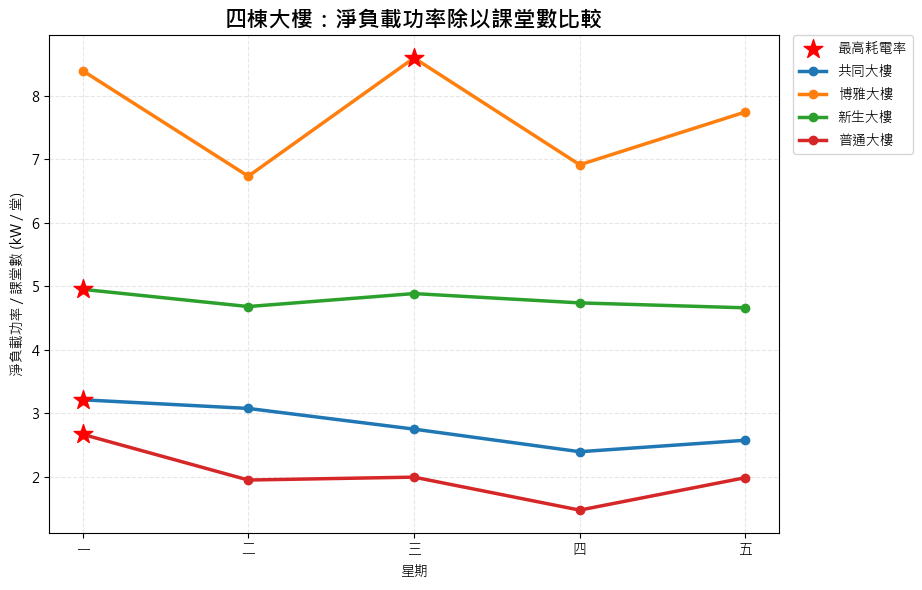

  Building  平均耗電率(kW/堂)  最高耗電率(kW/堂)  最高日
1       博雅     7.679543     8.599404  星期三
2       新生     4.783267     4.952035  星期一
0       共同     2.799773     3.210895  星期一
3       普通     2.011832     2.666456  星期一


In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

folder = r"C:\Users\admin\Desktop\環保能源\團體專題\final_project-data-preprocessing\output"
output_folder = r"C:\Users\admin\Desktop\環保能源\團體專題\output"
os.makedirs(output_folder, exist_ok=True)

buildings = ["共同", "博雅", "新生", "普通"]
building_colors = {
    "共同": "#1f77b4",  # 藍
    "博雅": "#ff7f0e",  # 橘
    "新生": "#2ca02c",  # 綠
    "普通": "#d62728"   # 紅
}
weekday_map = {
    "星期一": 1,
    "星期二": 2,
    "星期三": 3,
    "星期四": 4,
    "星期五": 5
}

weekday_labels = ["一", "二", "三", "四", "五"]

results = []

plt.figure(figsize=(11, 6))

for b in buildings:
    usage = pd.read_csv(os.path.join(folder, f"{b}_classroom_usage_day.csv"))
    power = pd.read_csv(os.path.join(folder, f"{b}_power_day.csv"))

    usage_melt = usage.melt(
        id_vars=["學年度學期", "星期"],
        var_name="時間區間",
        value_name="課堂數"
    )

    usage_melt["hour"] = usage_melt["時間區間"].str.slice(0, 2).astype(int)
    usage_melt = usage_melt[
        (usage_melt["hour"] >= 8) &
        (usage_melt["hour"] <= 16) &
        (usage_melt["星期"].isin(weekday_map.keys()))
    ]

    usage_weekday = usage_melt.groupby("星期")["課堂數"].sum().reset_index()

    power = power[(power["小時"] >= 8) & (power["小時"] <= 16)]

    saturday_power = power[power["星期"] == "星期六"]
    saturday_baseline = saturday_power.groupby("小時")["平均功率_kW"].mean().reset_index()
    saturday_baseline.rename(columns={"平均功率_kW": "星期六基準功率_kW"}, inplace=True)

    weekday_power = power[power["星期"].isin(weekday_map.keys())]

    power_net = pd.merge(
        weekday_power,
        saturday_baseline,
        on="小時",
        how="left"
    )

    power_net["淨負載_kW"] = power_net["平均功率_kW"] - power_net["星期六基準功率_kW"]

    net_power_weekday = power_net.groupby("星期")["淨負載_kW"].sum().reset_index()

    df = pd.merge(usage_weekday, net_power_weekday, on="星期")
    df["功率除以課堂數"] = df["淨負載_kW"] / df["課堂數"]
    df["weekday_num"] = df["星期"].map(weekday_map)
    df = df.sort_values("weekday_num")

    avg_rate = df["功率除以課堂數"].mean()
    max_rate = df["功率除以課堂數"].max()
    max_day = df.loc[df["功率除以課堂數"].idxmax(), "星期"]

    results.append({
        "Building": b,
        "平均耗電率(kW/堂)": avg_rate,
        "最高耗電率(kW/堂)": max_rate,
        "最高日": max_day
    })
        # 找最高點
    max_idx = df["功率除以課堂數"].idxmax()
    max_x = df.loc[max_idx, "weekday_num"]
    max_y = df.loc[max_idx, "功率除以課堂數"]

    # 用星號標記最高日 ⭐
    plt.scatter(
        max_x,
        max_y,
        color="red",
        s=200,
        marker="*",
        zorder=5,
        label="最高耗電率" if b == buildings[0] else None
        
    )
    plt.plot(
        df["weekday_num"],
        df["功率除以課堂數"],
        marker="o",
        linewidth=2.5,
        color=building_colors[b],   # ← 這行是重點
        label=f"{b}大樓"
    )

plt.xticks([1, 2, 3, 4, 5], weekday_labels)
plt.xlabel("星期")
plt.ylabel("淨負載功率 / 課堂數 (kW / 堂)")
plt.title("四棟大樓：淨負載功率除以課堂數比較", fontsize=16, fontweight="bold")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout(rect=[0, 0, 0.85, 1])

save_path = os.path.join(output_folder, "四棟大樓_淨負載功率除以課堂數_合併比較.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

result_df = pd.DataFrame(results)
result_df = result_df.sort_values("平均耗電率(kW/堂)", ascending=False)

print(result_df)

本研究發現，不同教學大樓之單位課堂耗電存在顯著差異，其中博雅大樓之平均耗電率約為普通大樓的近四倍，顯示建築設備或使用型態對能源效率具有主導影響。此外，多數大樓於星期一出現耗電高峰，反映啟動負載效應，而博雅大樓於星期三出現異常高值，推測可能與特定高耗能活動相關。

本研究採用兩階段異常值處理方法。首先，為避免課堂數過低導致比值不穩定，設定最小課堂數門檻為3，以降低分母過小造成之放大效應。其次，針對效率分布採用IQR四分位距法，剔除落在 Q1−1.5×IQR 與 Q3+1.5×IQR 範圍外之極端值，IQR 是用來處理「非對稱且含極端值資料」的標準方法，以確保分析結果之穩定性與代表性。

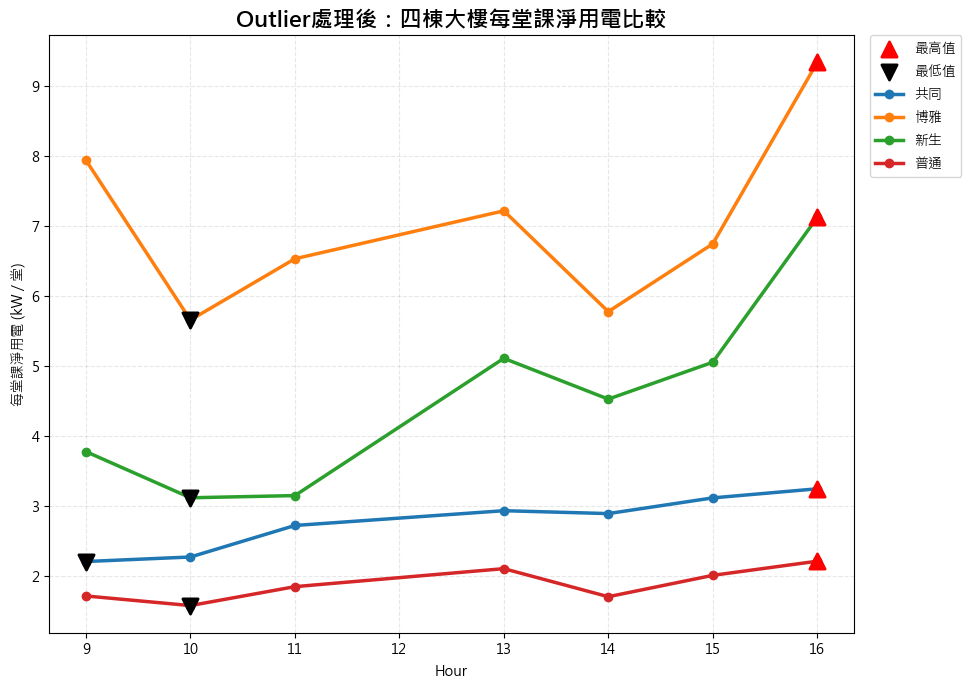


=== 每堂課淨用電（clean） ===
  Building        平均        最大        最小
0       共同  2.772584  3.248208  2.210876
1       博雅  7.025491  9.329037  5.656038
2       新生  4.551180  7.118491  3.120129
3       普通  1.885925  2.215482  1.582572


In [37]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

folder = r"C:\Users\admin\Desktop\環保能源\團體專題\final_project-data-preprocessing\output"

buildings = ["共同", "博雅", "新生", "普通"]
weekday_list = ["星期一", "星期二", "星期三", "星期四", "星期五"]

building_colors = {
    "共同": "#1f77b4",  # 藍
    "博雅": "#ff7f0e",  # 橘
    "新生": "#2ca02c",  # 綠
    "普通": "#d62728"   # 紅
}

plt.figure(figsize=(12, 7))
summary = []

for i, b in enumerate(buildings):
    usage = pd.read_csv(os.path.join(folder, f"{b}_classroom_usage_day.csv"))
    power = pd.read_csv(os.path.join(folder, f"{b}_power_day.csv"))

    # =========================
    # 1. 課堂數
    # =========================
    usage_melt = usage.melt(
        id_vars=["學年度學期", "星期"],
        var_name="時間區間",
        value_name="課堂數"
    )

    usage_melt["hour"] = usage_melt["時間區間"].str.slice(0, 2).astype(int)

    usage_melt = usage_melt[
        (usage_melt["hour"] >= 9) &
        (usage_melt["hour"] <= 16) &
        (usage_melt["星期"].isin(weekday_list))
    ]

    usage_avg = usage_melt.groupby("hour")["課堂數"].mean().reset_index()

    # =========================
    # 2. 功率 → 淨負載
    # =========================
    power_filtered = power[(power["小時"] >= 9) & (power["小時"] <= 16)]

    saturday_baseline = (
        power_filtered[power_filtered["星期"] == "星期六"]
        .groupby("小時")["平均功率_kW"]
        .mean()
        .reset_index()
        .rename(columns={"平均功率_kW": "星期六基準功率_kW"})
    )

    weekday_power = power_filtered[power_filtered["星期"].isin(weekday_list)]

    power_avg = (
        weekday_power
        .groupby("小時")["平均功率_kW"]
        .mean()
        .reset_index()
    )

    power_avg = pd.merge(power_avg, saturday_baseline, on="小時", how="left")
    power_avg["淨負載_kW"] = power_avg["平均功率_kW"] - power_avg["星期六基準功率_kW"]
    power_avg.rename(columns={"小時": "hour"}, inplace=True)

    # =========================
    # 3. 每堂課用電
    # =========================
    df = pd.merge(usage_avg, power_avg, on="hour")
    df["每堂課淨用電(kW/堂)"] = df["淨負載_kW"] / df["課堂數"]

    # =========================
    # 4. Outlier 清理
    # =========================
    df_clean = df[df["課堂數"] >= 3].copy()

    Q1 = df_clean["每堂課淨用電(kW/堂)"].quantile(0.25)
    Q3 = df_clean["每堂課淨用電(kW/堂)"].quantile(0.75)
    IQR = Q3 - Q1

    df_clean = df_clean[
        (df_clean["每堂課淨用電(kW/堂)"] >= Q1 - 1.5 * IQR) &
        (df_clean["每堂課淨用電(kW/堂)"] <= Q3 + 1.5 * IQR)
    ]

    if df_clean.empty:
        continue

    # =========================
    # 5. 畫線
    # =========================
    plt.plot(
        df_clean["hour"],
        df_clean["每堂課淨用電(kW/堂)"],
        marker="o",
        linewidth=2.5,
        color=building_colors[b],   # ← 這行是重點
        label=f"{b}",
        zorder=3
    )

    # =========================
    # 6. 找最高 / 最低（正確位置）
    # =========================
    max_idx = df_clean["每堂課淨用電(kW/堂)"].idxmax()
    max_x = df_clean.loc[max_idx, "hour"]
    max_y = df_clean.loc[max_idx, "每堂課淨用電(kW/堂)"]

    min_idx = df_clean["每堂課淨用電(kW/堂)"].idxmin()
    min_x = df_clean.loc[min_idx, "hour"]
    min_y = df_clean.loc[min_idx, "每堂課淨用電(kW/堂)"]

    # ⭐ 最高值（空心，不遮線）
    plt.scatter(
        max_x, max_y,
        facecolors="red",
        edgecolors="red",
        marker="^",
        s=120,
        linewidths=2,
        zorder=6,
        label="最高值" if i == 0 else None
    )

    # ▼ 最低值（空心）
    plt.scatter(
        min_x, min_y,
        facecolors="black",
        edgecolors="black",
        marker="v",
        s=120,
        linewidths=2,
        zorder=6,
        label="最低值" if i == 0 else None
    )

    # =========================
    # 7. 統計
    # =========================
    summary.append({
        "Building": b,
        "平均": df_clean["每堂課淨用電(kW/堂)"].mean(),
        "最大": df_clean["每堂課淨用電(kW/堂)"].max(),
        "最小": df_clean["每堂課淨用電(kW/堂)"].min()
    })

# =========================
# 8. 圖表設定
# =========================
plt.title("Outlier處理後：四棟大樓每堂課淨用電比較", fontsize=16, fontweight="bold")
plt.xlabel("Hour")
plt.ylabel("每堂課淨用電 (kW / 堂)")
plt.grid(True, linestyle="--", alpha=0.3)

# 👉 Legend 排序（重點）
# 👉 Legend 放到圖表右邊，並包含四棟大樓 + 最高值 + 最低值
handles, labels = plt.gca().get_legend_handles_labels()

legend_order = ["最高值", "最低值", "共同", "博雅", "新生", "普通"]

ordered_handles = []
ordered_labels = []

for name in legend_order:
    if name in labels:
        idx = labels.index(name)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

plt.legend(
    ordered_handles,
    ordered_labels,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.82, 1])

save_path = os.path.join(output_folder, "四棟大樓每堂課淨用電比較.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
output_folder = r"C:\Users\admin\Desktop\環保能源\團體專題\output"
os.makedirs(output_folder, exist_ok=True)
# =========================
# 9. 表格
# =========================
summary_df = pd.DataFrame(summary)
print("\n=== 每堂課淨用電（clean） ===")
print(summary_df)

逐小時分析結合異常值剔除後，可有效揭示建築能源效率之真實分布，並確認博雅大樓為高耗能建築，而中午時段為主要效率下降之關鍵時間點。